In [257]:
from mpl_toolkits import mplot3d
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import sympy as sp
from scipy.fft import fftn, fftfreq, fftshift
from mpl_toolkits.mplot3d import Axes3D
from scipy.special import jv, kv

In [258]:
#CONSTANTS
c = 299792458.0
e = 1.60217663e-19
eps0 = 8.854187812e-12
m_e_MeV = 0.51099895

In [259]:
#ARES parameters
beta = 0.999987
gamma = 196.69
pulseduration = 1e-15
bunchcharge = 5e-12
beamsize = 50e-6

#Charge of a single e-
e = 1.6e-19

In [260]:
#ARES ENERGY PARAMETERS
E_MeV = 100
E_total = E_MeV + m_e_MeV
gamma = E_total / m_e_MeV
beta = np.sqrt(1 - 1 / gamma**2)
v = beta * c

In [261]:
#ARES CHARGE PARAMETERS
bunchcharge = 5e-12
Ne = bunchcharge/e

In [262]:
#ARES BEAM PARAMETERS
sigma_x = sigma_y = 1e-3

In [263]:
#TEMPORAL PULSE (in sec)
taus_fwhm_s_list = [1e-6, 1e-9, 1e-12, 1e-15, 1e-20]

In [264]:
sigma_t = taus_fwhm_s_list/ (2*np.sqrt(2*np.log(2))) #FWHM
sigma_z = c * np.array(taus_fwhm_s_list) #m/s * s --> m 

sigma_t = taus_fwhm_s_list/ (2*np.sqrt(2*np.log(2))) #FWHM
sigma_z = c * sigma_t #m/s * s --> m 

In [265]:
from scipy.special import eval_laguerre

def cartesian_gaussian_form_factor(kx, ky, kz, tau_fwhm_s, sigma_r, l):
    sigma_z = c * tau_fwhm_s
    term1 = np.exp(- (sigma_z**2*kz**2)/4)
    arg = ((sigma_r**2)/4) * (kx**2 + ky**2)
    term2 = eval_laguerre(l, arg)
    term3 = np.exp(- (sigma_r**2)/4 * (kx**2 + ky**2))
    
    F = term1 * term2 * term3
    return F
    

In [266]:
#OBSERVATION GRIDS
c = 3e8
Nangle, Nlam = 200, 500
th = np.linspace(-0.4, 0.4, Nangle)
lam = np.linspace(1e-6,1e-5, Nlam)
phi = np.linspace(0, 2*np.pi, Nangle, endpoint=False)
TH, LAM = np.meshgrid(th, lam,  indexing='ij')
#we can also do
#PHI, TH, LAM = meshgrid(phi, th, lam, indexing='ij')
PHI = 0

OMEGA = 2*np.pi*c/LAM # w = 2pif = 2pi(v/lamda) = (2pi*c)/lambda --> angular frequency 

k = OMEGA/c

#calcualtes the kx ky andn kz over all combinations of Th and PHI
kx = k * np.sin(TH) * np.cos(PHI)
ky = k * np.sin(TH) * np.sin(PHI)
kz = k * np.cos(TH)

print(th.shape)
print(lam.shape)
print(kx.shape)
print(ky.shape)
print(TH.shape)
print(LAM.shape)



(200,)
(500,)
(200, 500)
(200, 500)
(200, 500)
(200, 500)


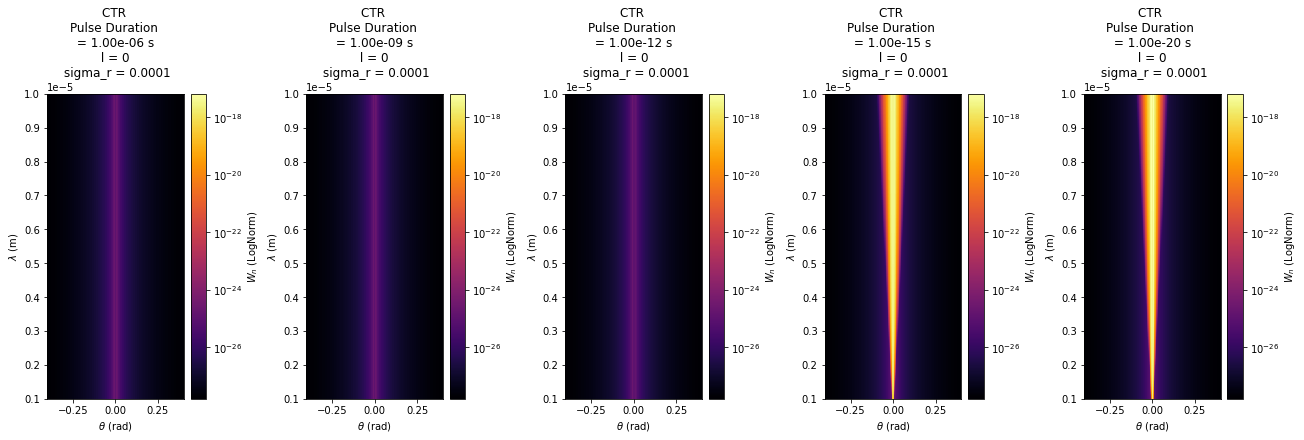

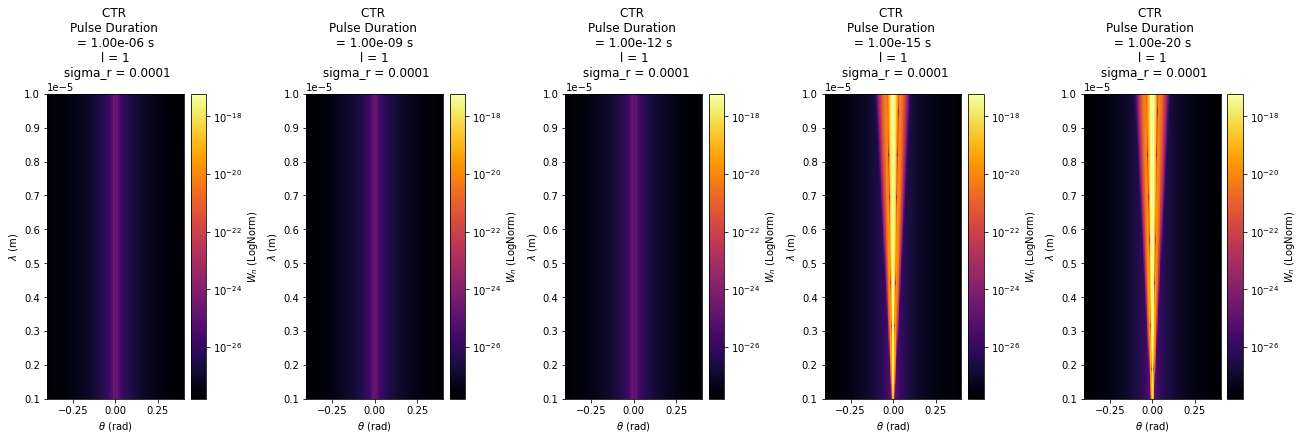

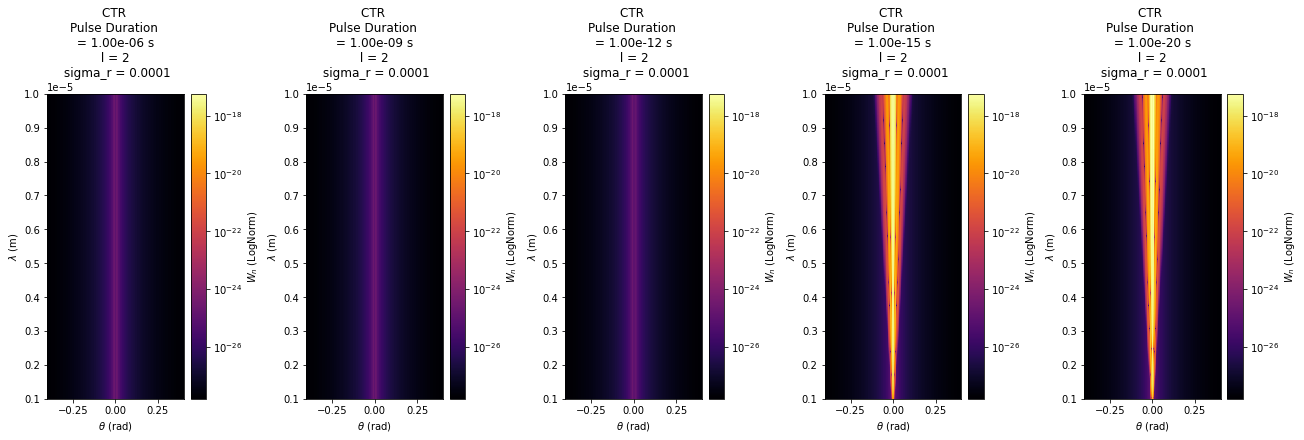

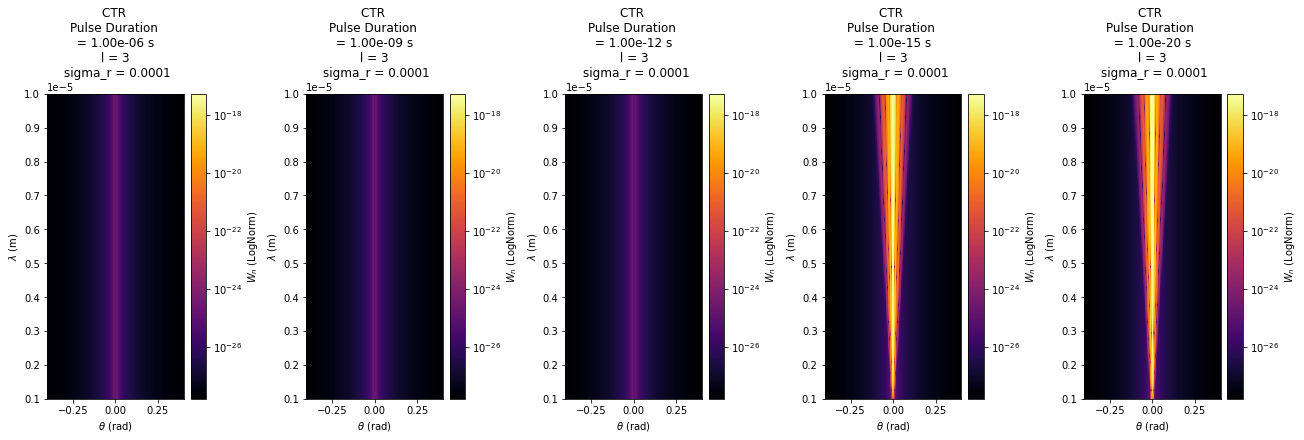

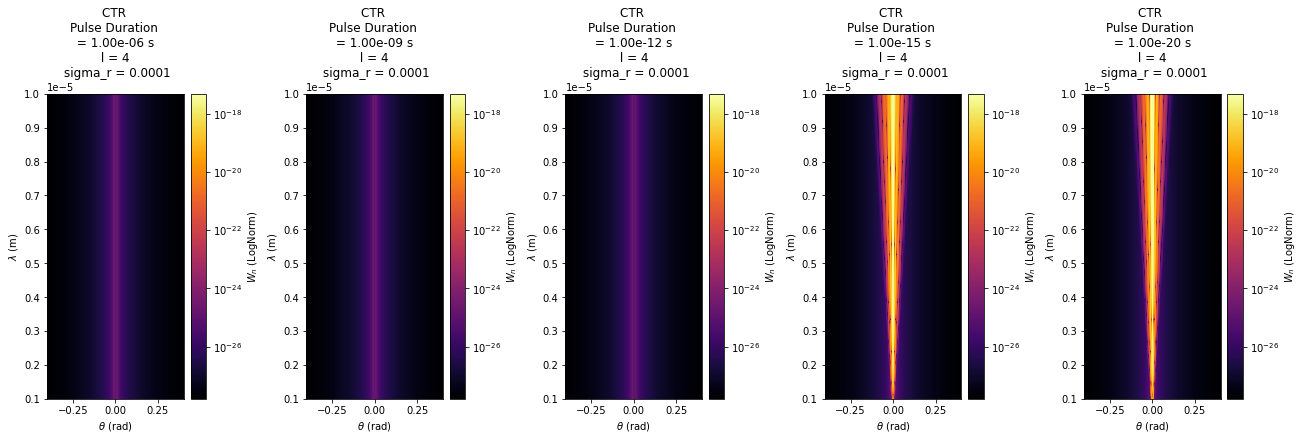

(6, 200, 500)


In [267]:
from matplotlib.colors import LogNorm

sigma_r = 100e-6
l = 1

for l in range(5):
    # single-electron angular factor
    A  = e**2 / (4*np.pi*eps0*c)
    W1 = A * (beta**2 * np.sin(TH)**2) / (1.0 - beta**2 * np.cos(TH)**2)**2

    Wn_list = []
    for tau_s in taus_fwhm_s_list:  
        F = cartesian_gaussian_form_factor(kx, ky, kz, tau_s, sigma_r, l)
        F2 = np.abs(F)**2
        Wn = W1 * (Ne + Ne * (Ne - 1) * F2)
        Wn_list.append(Wn)


    Wn_list.append(W1 * (Ne + Ne*(Ne-1)*F2))
    stack = np.stack(Wn_list, axis=0)

    positive = stack[stack > 0]
    vmin = np.percentile(positive, 1) if positive.size else 1e-30
    vmax = stack.max()


#PLOTTING

    fig, axes = plt.subplots(1, len(taus_fwhm_s_list), figsize=(18,6), constrained_layout=True)
    for ax, Wn, tau_s in zip(axes, Wn_list, taus_fwhm_s_list):
            im = ax.pcolormesh(th, lam, np.maximum(Wn.T, vmin), shading='nearest', cmap='inferno', norm=LogNorm(vmin=vmin, vmax=vmax))
            ax.set_title(f'CTR \nPulse Duration \n = {tau_s:.2e} s \n l = {l} \n sigma_r = {sigma_r}')
            ax.set_xlabel(r'$\theta$ (rad)')
            ax.set_ylabel(r'$\lambda$ (m)')
            ax.set_ylim(lam.min(), lam.max())
            cb = plt.colorbar(im, ax=ax)
            cb.set_label(r'$W_n$ (LogNorm)')
    plt.show()

print(np.array(Wn_list).shape)


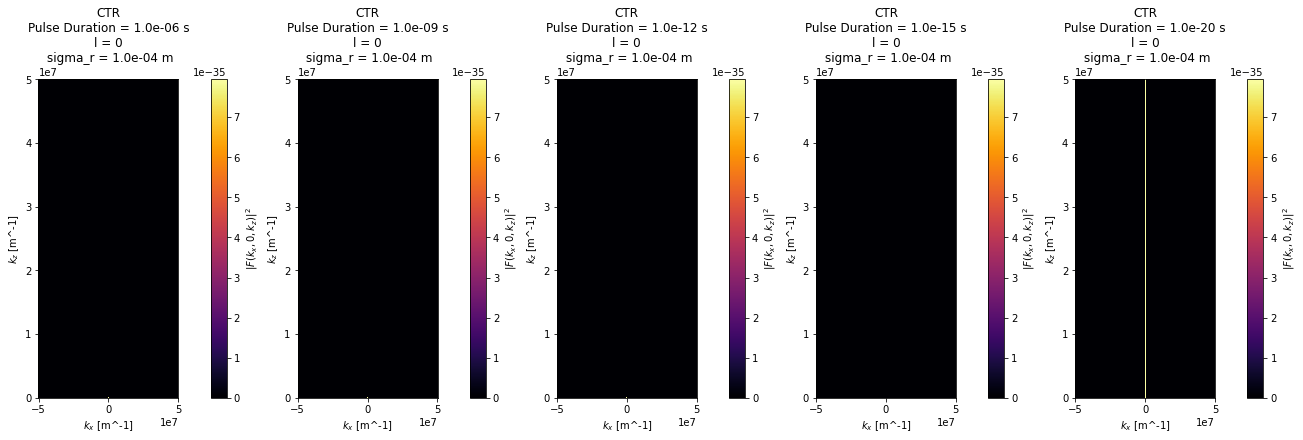

In [269]:
ky = 0.0 #if PHI is 0, ky = 0
Nk = 400
kx_max = 5e7
kz_max = 5e7
kx = np.linspace(-kx_max, kx_max, Nk)
kz =  np.linspace( 0.0,   kz_max, Nk)
KX, KZ = np.meshgrid(kx , kz , indexing='ij')

l = 0

    
fig, axes = plt.subplots(1, len(taus_fwhm_s_list), figsize=(18,6), constrained_layout=True)
for ax, tau_s in zip(axes, taus_fwhm_s_list):
    #compute form factor for this pulse duration
    F = cartesian_gaussian_form_factor(KX, ky, KZ, tau_s, sigma_r, l)
    F2 = np.abs(F)**2

    #I just copied the earlier code over in a smilar manner
    positive = F2[F2 > 0]
    vmin = np.percentile(positive, 1) if positive.size else 1e-30
    vmax = positive.max()

    #Also plotting in a similar manner but I auto generated the labels for the x and y axis so it looks cleaner
    im = ax.pcolormesh(kx, kz, F2.T, shading='auto',
                       cmap='inferno')
    ax.set_title(f'CTR\nPulse Duration = {tau_s:.1e} s\nl = {l}\n sigma_r = {sigma_r:.1e} m')
    ax.set_xlabel(r'$k_x$ [m^-1]')
    ax.set_ylabel(r'$k_z$ [m^-1]')

    cb = plt.colorbar(im, ax=ax)
    cb.set_label(r'$|F(k_x,0,k_z)|^2$')

plt.show()
